In [ ]:
# Milestone 2: Temporal Analysis of US Natural Disaster Declarations
#Objective:  To analyze temporal trends, incident type evolution, and seasonality patterns in US disaster declarations.

In [ ]:
# 1. Importing Required Libraries
# This section imports the necessary Python libraries for data analysis and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [34]:
#2. Loading the Dataset
#The dataset is loaded into a pandas DataFrame.

df = pd.read_csv("database.csv")
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [31]:
# 3. Data Validation and Preprocessing
# 3.1 Checking Column Names
df.columns

Index(['Declaration Number', 'Declaration Type', 'Declaration Date', 'State',
       'County', 'Disaster Type', 'Disaster Title', 'Start Date', 'End Date',
       'Close Date', 'Individual Assistance Program',
       'Individuals & Households Program', 'Public Assistance Program',
       'Hazard Mitigation Program'],
      dtype='object')

In [35]:
# 3.2 Converting Declaration Date to Datetime Format

df["Declaration Date"] = pd.to_datetime(df["Declaration Date"], errors='coerce')

In [36]:
# 3.3 Handling Missing or Invalid Dates
df["Declaration Date"].isnull().sum()
df = df.dropna(subset=["Declaration Date"])

In [37]:
# 3.4 Extracting Year and Month

df["year"] = df["Declaration Date"].dt.year
df["month"] = df["Declaration Date"].dt.month

df[["Declaration Date", "year", "month"]].head()

,Declaration Date,year,month
0,1953-05-02,1953,5
1,1953-05-15,1953,5
2,1953-05-29,1953,5
3,1953-06-02,1953,6
4,1953-06-06,1953,6


In [38]:
# 4. Yearly Trend Analysis
#4.1 Grouping Data by Year
yearly_counts = df.groupby("year").size()
yearly_counts.head()


year
1953    13
1954    17
1955    18
1956    16
1957    16
dtype: int64

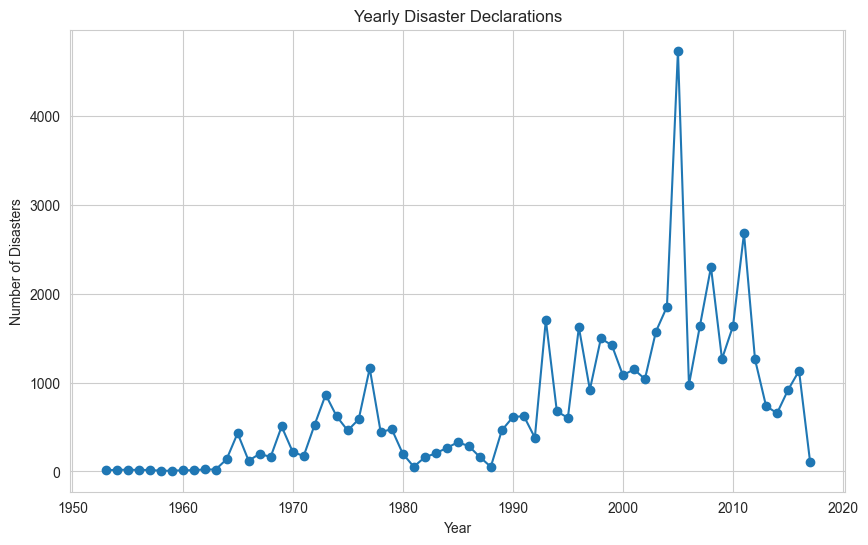

In [39]:
# 4.2 Visualization of Yearly Disaster Trends
plt.figure()
plt.plot(yearly_counts.index, yearly_counts.values, marker="o")

plt.title("Yearly Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()

In [40]:
# 4.3 Insight Interpretation

#1. The graph shows the number of disaster declarations per year.
#2. There is an observable increasing/decreasing trend.
#3. Possible reasons include climate changes, policy changes, or reporting improvements.

In [41]:
#5. Incident Type Trends Over Time
# 5.1 Grouping by Year and Incident Type

incident_trend = df.groupby(["year", "Declaration Type"]).size().unstack()
incident_trend.head()

Declaration Type,Disaster,Emergency,Fire
year,,,
1953,13.0,NaN,NaN
1954,17.0,NaN,NaN
1955,18.0,NaN,NaN
1956,16.0,NaN,NaN
1957,16.0,NaN,NaN


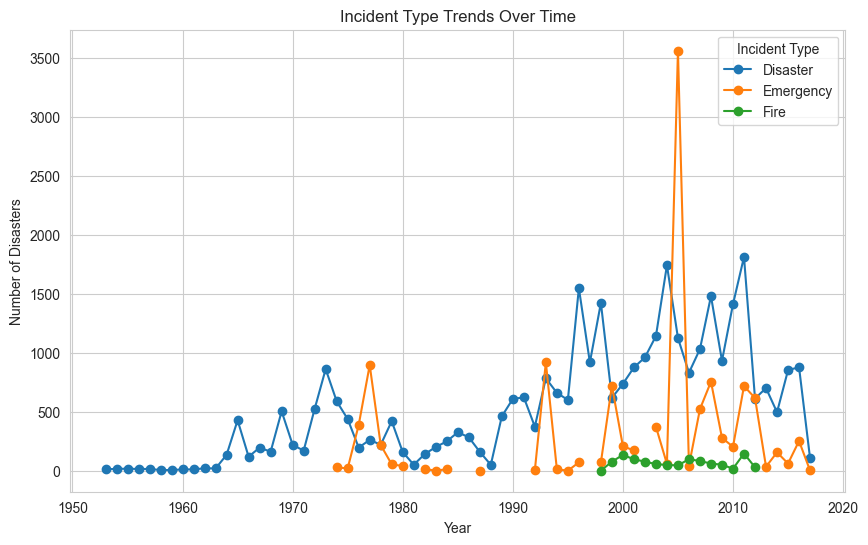

In [42]:
# 5.2 Multi-Line Trend Visualization
incident_trend.plot(marker="o")

plt.title("Incident Type Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend(title="Incident Type")
plt.show()

In [43]:
#5.3 Insight Interpretation

#1. The graph compares different disaster types across years.
#2. Some incident types show increasing trends.
#3. Certain disasters dominate specific periods.

In [44]:
#6. Seasonality Analysis (Monthly Trends)

# 6.1 Grouping Data by Month

monthly_counts = df.groupby("month").size()
monthly_counts

month
1     4630
2     3526
3     4633
4     3636
5     4231
6     4041
7     3883
8     3602
9     8281
10    2673
11    1341
12    1708
dtype: int64

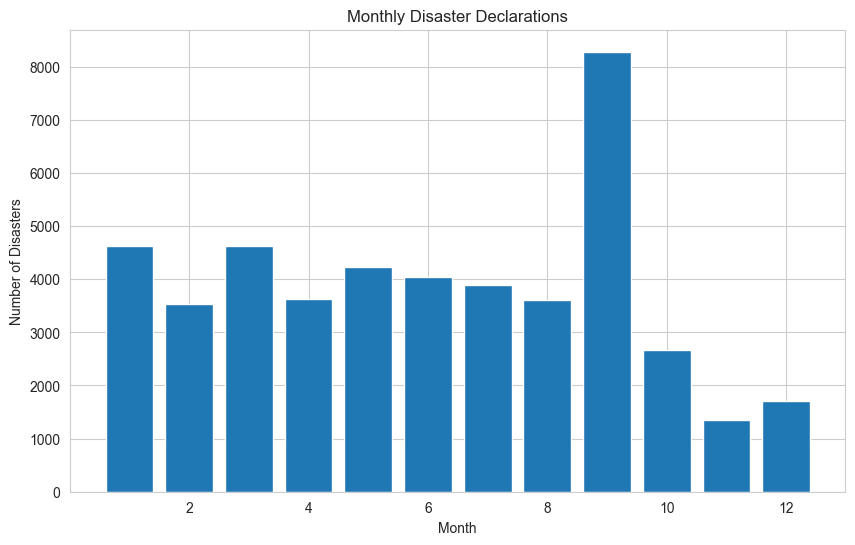

In [45]:
# 6.2 Monthly Trend Visualization
plt.figure()
plt.bar(monthly_counts.index, monthly_counts.values)

plt.title("Monthly Disaster Declarations")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.show()

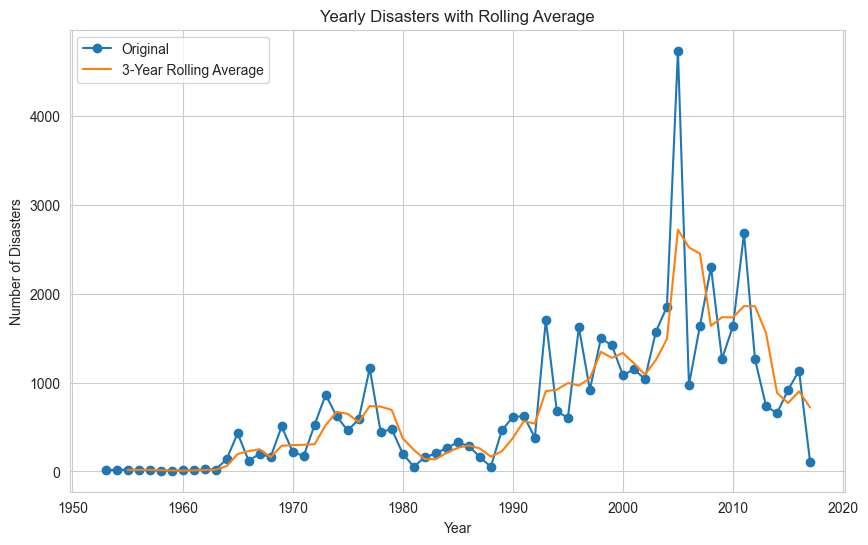

In [46]:
# 7. Advanced Time-Based Insights

#7.1 Rolling Average Analysis
rolling_avg = yearly_counts.rolling(window=3).mean()

plt.figure()
plt.plot(yearly_counts.index, yearly_counts.values, label="Original", marker="o")
plt.plot(rolling_avg.index, rolling_avg.values, label="3-Year Rolling Average")

plt.title("Yearly Disasters with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.show()

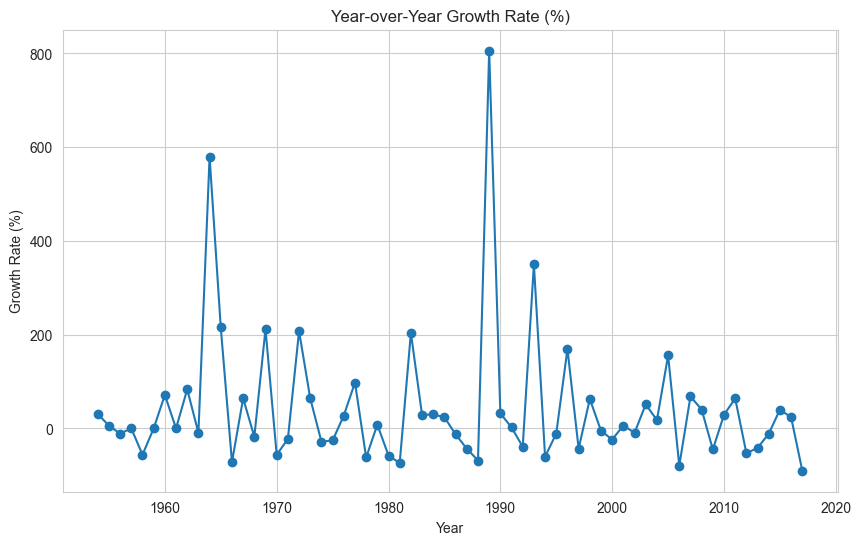

In [47]:
# 7.2 Year-over-Year Growth Rate
growth_rate = yearly_counts.pct_change() * 100

plt.figure()
plt.plot(growth_rate.index, growth_rate.values, marker="o")

plt.title("Year-over-Year Growth Rate (%)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

In [48]:
# 8. Conclusion

#The temporal analysis reveals long-term trends, seasonal patterns, and evolving disaster types in the United States. These findings help understand changes in disaster frequency over time.